# NewsQA Dataset Exploration

NewsQA reading comprehension dataset (~74K train + ~4K val examples).  
CNN news articles with crowdsourced extractive questions.  
HuggingFace: `lucadiliello/newsqa`

Columns: `context` (str), `question` (str), `answers` (list[str]), `key` (str), `labels` (char offsets)

In [1]:
%load_ext autoreload
%autoreload 2

In [11]:
import os
from pathlib import Path
from pprint import pprint
import sys
from typing import Optional, List, Dict, Any, Tuple
if '..' not in sys.path: sys.path.append('..')

from datasets import load_dataset
from datasets.arrow_dataset import Dataset
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from transformers import AutoTokenizer, PreTrainedTokenizer

tkz = AutoTokenizer.from_pretrained('bert-base-uncased')
print(f'Tokenizer vocab size: {tkz.vocab_size}')

Tokenizer vocab size: 30522


In [12]:
DATA_PATH = Path('Q:/data')
QNA_DATA_PATH = DATA_PATH / 'qna'
QNA_DATA_PATH.mkdir(parents=True, exist_ok=True)

# NewsQA on HuggingFace: the 'lucadiliello/newsqa' version has a clean extractive format
# Alternative: MRQA shared task includes NewsQA in a unified format
NEWSQA_HF_ID = 'lucadiliello/newsqa'
print(f'DATA_PATH: {DATA_PATH}')
print(f'NEWSQA_HF_ID: {NEWSQA_HF_ID}')

DATA_PATH: Q:\data
NEWSQA_HF_ID: lucadiliello/newsqa


## Load NewsQA

In [13]:
# Load NewsQA from HuggingFace
ds_newsqa = load_dataset(NEWSQA_HF_ID, cache_dir=str(DATA_PATH), trust_remote_code=True)
print(f'Splits: {list(ds_newsqa.keys())}')
for split_name, split_ds in ds_newsqa.items():
    print(f'  {split_name}: {len(split_ds)} examples')
print(f'\nFeatures: {list(ds_newsqa["train"].features.keys())}')

Splits: ['train', 'validation']
  train: 74160 examples
  validation: 4212 examples

Features: ['context', 'question', 'answers', 'key', 'labels']


In [14]:
# Examine the structure of one example
ex = ds_newsqa['train'][0]
print('Keys:', list(ex.keys()))
print()
for k, v in ex.items():
    if isinstance(v, str):
        print(f'{k}: {v[:200]}{"..." if len(v) > 200 else ""}')
    elif isinstance(v, dict):
        print(f'{k}: {v}')
    elif isinstance(v, list):
        print(f'{k}: {v[:5]}{"..." if len(v) > 5 else ""}')
    else:
        print(f'{k}: {v}')

Keys: ['context', 'question', 'answers', 'key', 'labels']

context: NEW DELHI, India (CNN) -- A high court in northern India on Friday acquitted a wealthy businessman facing the death sentence for the killing of a teen in a case dubbed "the house of horrors."



Monin...
question: What was the amount of children murdered?
answers: ['19']
key: da0e6b66e04d439fa1ba23c32de07e50
labels: [{'end': [295], 'start': [294]}]


## Dataset Statistics

In [15]:
# Convert to DataFrame for easier analysis
ds_train = ds_newsqa['train']
df_newsqa = ds_train.to_pandas()
n_total = len(df_newsqa)
print(f'Train DataFrame: {df_newsqa.shape}')
print(f'Columns: {list(df_newsqa.columns)}')
print()

# All rows have context, question, and at least one answer
n_empty_ans = (df_newsqa['answers'].apply(len) == 0).sum()
print(f'Rows with empty answers: {n_empty_ans}/{n_total}')
print(f'Sample answers:')
for i in range(3):
    print(f'  [{i}] {df_newsqa["answers"].iloc[i]}')

Train DataFrame: (74160, 5)
Columns: ['context', 'question', 'answers', 'key', 'labels']

Rows with empty answers: 0/74160
Sample answers:
  [0] ['19']
  [1] ['February.']
  [2] ['rape and murder']


In [16]:
# Unique context (story) count — NewsQA has many questions per CNN article
n_unique_stories = df_newsqa['context'].nunique()
print(f'Total rows: {n_total}')
print(f'Unique stories/contexts: {n_unique_stories}')
print(f'Questions per story: ~{n_total / max(n_unique_stories, 1):.1f}')

# Answer count distribution (most rows have 1 answer)
ans_counts = df_newsqa['answers'].apply(len)
print(f'\nAnswers per question: mean={ans_counts.mean():.2f}, max={ans_counts.max()}')
print(ans_counts.value_counts().sort_index())

Total rows: 74160
Unique stories/contexts: 10895
Questions per story: ~6.8

Answers per question: mean=1.00, max=1
answers
1    74160
Name: count, dtype: int64


Answer char lengths:
count    74160.000000
mean        25.021508
std         28.281497
min          1.000000
25%          9.000000
50%         16.000000
75%         30.000000
max        600.000000
Name: answers, dtype: float64

Questions per story distribution:
count    10895.000000
mean         6.806792
std          3.071964
min          1.000000
25%          5.000000
50%          7.000000
75%          8.000000
max         39.000000
dtype: float64


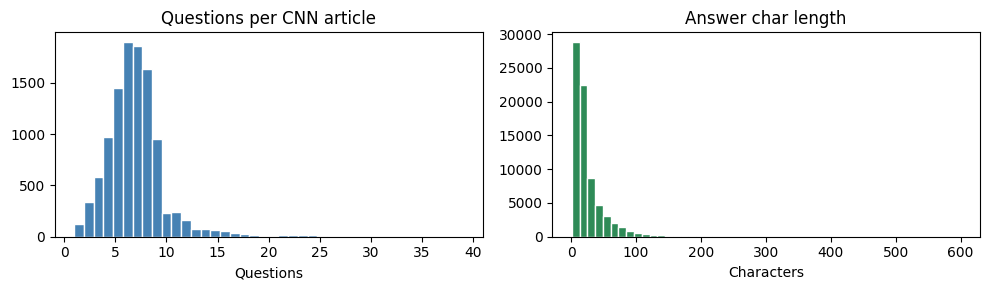

In [17]:
# Answer length distribution (chars)
ans_char_lens = df_newsqa['answers'].apply(lambda a: len(a[0]) if len(a) > 0 else 0)
print('Answer char lengths:')
print(ans_char_lens.describe())

# Questions per unique story — distribution
story_q_counts = df_newsqa.groupby('context').size()
print(f'\nQuestions per story distribution:')
print(story_q_counts.describe())

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(story_q_counts.values, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Questions per CNN article')
axes[0].set_xlabel('Questions')

axes[1].hist(ans_char_lens.values, bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Answer char length')
axes[1].set_xlabel('Characters')

plt.tight_layout()
plt.show()

## Inspect Examples

In [18]:
# Display a few examples
for i in range(5):
    row = df_newsqa.iloc[i]
    context = row['context']
    question = row['question']
    answers = row['answers']
    labels = row['labels']

    print(f'=== Example {i} ===')
    print(f'  Question: {question}')
    print(f'  Answers:  {answers}')
    print(f'  Context:  {context[:300].replace(chr(10), " ")}...')

    # Show answer span in context using char labels
    if labels and len(labels) > 0:
        lbl = labels[0]
        start, end = lbl['start'][0], lbl['end'][0]
        span = context[start:end]
        ctx_off = 30
        beg = max(start - ctx_off, 0)
        ctx_around = context[beg:end + ctx_off]
        print(f'  Span [{start}:{end}]: "{span}"')
        print(f'  In context: "...{ctx_around}..."')
    print()

=== Example 0 ===
  Question: What was the amount of children murdered?
  Answers:  ['19']
  Context:  NEW DELHI, India (CNN) -- A high court in northern India on Friday acquitted a wealthy businessman facing the death sentence for the killing of a teen in a case dubbed "the house of horrors."    Moninder Singh Pandher was sentenced to death by a lower court in February.    The teen was one of 19 vic...
  Span [294:295]: "1"
  In context: "...ruary.



The teen was one of 19 victims -- children and youn..."

=== Example 1 ===
  Question: When was Pandher sentenced to death?
  Answers:  ['February.']
  Context:  NEW DELHI, India (CNN) -- A high court in northern India on Friday acquitted a wealthy businessman facing the death sentence for the killing of a teen in a case dubbed "the house of horrors."    Moninder Singh Pandher was sentenced to death by a lower court in February.    The teen was one of 19 vic...
  Span [261:269]: "February"
  In context: "... to death by a lower court in 

## Context / Answer Length Distributions

In [19]:
# Tokenize contexts, questions, answers and measure lengths
nqa_ctx_lens = []
nqa_q_lens = []
nqa_ans_lens = []

for _, row in df_newsqa.iterrows():
    ctx_toks = tkz(row['context'], add_special_tokens=False).input_ids
    q_toks = tkz(row['question'], add_special_tokens=False).input_ids
    ans_toks = tkz(row['answers'][0], add_special_tokens=False).input_ids

    nqa_ctx_lens.append(len(ctx_toks))
    nqa_q_lens.append(len(q_toks))
    nqa_ans_lens.append(len(ans_toks))

nqa_ctx_lens = np.array(nqa_ctx_lens)
nqa_q_lens = np.array(nqa_q_lens)
nqa_ans_lens = np.array(nqa_ans_lens)

print(f'Processed {len(nqa_ctx_lens)} examples')
print('\nContext token lengths:')
print(f'  mean={nqa_ctx_lens.mean():.1f}, median={np.median(nqa_ctx_lens):.1f}, '
      f'min={nqa_ctx_lens.min()}, max={nqa_ctx_lens.max()}, std={nqa_ctx_lens.std():.1f}')
print('Question token lengths:')
print(f'  mean={nqa_q_lens.mean():.1f}, median={np.median(nqa_q_lens):.1f}, '
      f'min={nqa_q_lens.min()}, max={nqa_q_lens.max()}, std={nqa_q_lens.std():.1f}')
print('Answer token lengths:')
print(f'  mean={nqa_ans_lens.mean():.1f}, median={np.median(nqa_ans_lens):.1f}, '
      f'min={nqa_ans_lens.min()}, max={nqa_ans_lens.max()}, std={nqa_ans_lens.std():.1f}')

Token indices sequence length is longer than the specified maximum sequence length for this model (515 > 512). Running this sequence through the model will result in indexing errors


Processed 74160 examples

Context token lengths:
  mean=641.3, median=693.0, min=23, max=1043, std=215.1
Question token lengths:
  mean=8.2, median=8.0, min=2, max=150, std=2.9
Answer token lengths:
  mean=5.7, median=4.0, min=1, max=208, std=6.0


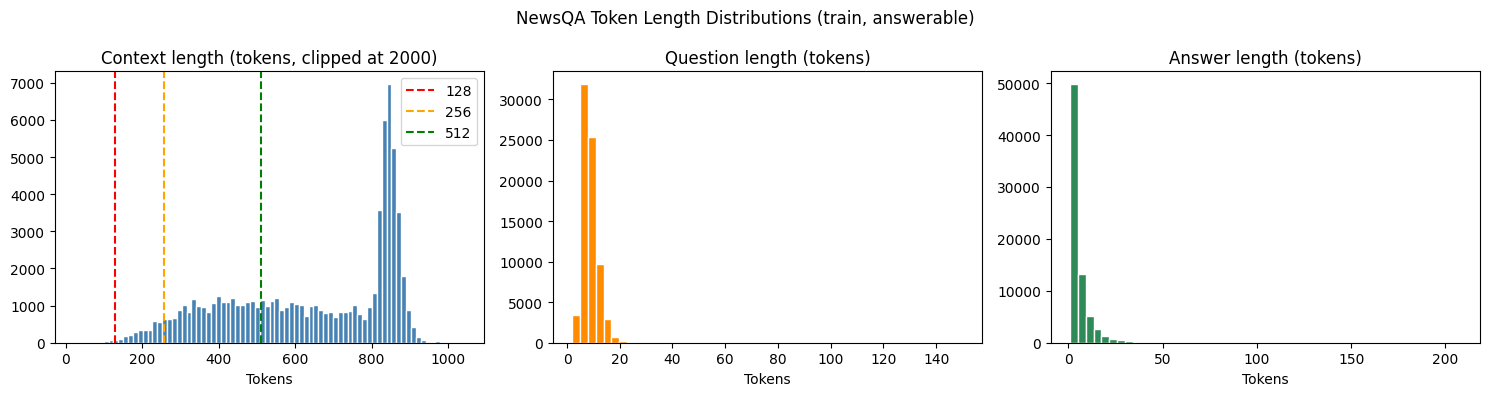

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# NewsQA contexts (CNN articles) are moderately long — clip at 2000 for visualization
ctx_clip = np.clip(nqa_ctx_lens, 0, 2000)
axes[0].hist(ctx_clip, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Context length (tokens, clipped at 2000)')
axes[0].set_xlabel('Tokens')
axes[0].axvline(128, color='red', linestyle='--', label='128')
axes[0].axvline(256, color='orange', linestyle='--', label='256')
axes[0].axvline(512, color='green', linestyle='--', label='512')
axes[0].legend()

axes[1].hist(nqa_q_lens, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Question length (tokens)')
axes[1].set_xlabel('Tokens')

axes[2].hist(nqa_ans_lens, bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Answer length (tokens)')
axes[2].set_xlabel('Tokens')

plt.suptitle('NewsQA Token Length Distributions (train, answerable)')
plt.tight_layout()
plt.show()

In [21]:
# Chunk analysis
for inp_len in [128, 256, 384, 512]:
    chunk_content = inp_len - 2
    n_chunks = np.ceil(nqa_ctx_lens / chunk_content).astype(int)
    multi = (n_chunks > 1).sum()
    print(f'inp_len={inp_len}: need >1 chunk: {multi}/{len(nqa_ctx_lens)} ({multi/len(nqa_ctx_lens):.1%}), '
          f'max chunks: {n_chunks.max()}, mean chunks: {n_chunks.mean():.2f}')

inp_len=128: need >1 chunk: 73974/74160 (99.7%), max chunks: 9, mean chunks: 5.53
inp_len=256: need >1 chunk: 70926/74160 (95.6%), max chunks: 5, mean chunks: 3.09
inp_len=384: need >1 chunk: 62140/74160 (83.8%), max chunks: 3, mean chunks: 2.27
inp_len=512: need >1 chunk: 51235/74160 (69.1%), max chunks: 3, mean chunks: 1.69


## Convert to Unified QnA Format

In [ ]:
# Convert NewsQA to unified QnA format: (context, question, answer, source)
# Combine train + validation splits
rows_unified = []
for split_name in ds_newsqa.keys():
    ds_split = ds_newsqa[split_name]
    for i in range(len(ds_split)):
        ex = ds_split[i]
        context = ex['context']
        question = ex['question']
        answers = ex['answers']
        if not answers or not context.strip() or not question.strip():
            continue
        rows_unified.append({
            'context': context,
            'question': question,
            'answer': answers[0],
            'source': 'newsqa',
        })

df_unified_nqa = pd.DataFrame(rows_unified)
print(f'Unified NewsQA rows (all splits): {len(df_unified_nqa)}')
df_unified_nqa.head()

In [ ]:
# Save unified format
unified_fpath = QNA_DATA_PATH / 'newsqa_unified.parquet'
df_unified_nqa.to_parquet(unified_fpath, index=False)
print(f'Saved to {unified_fpath} ({len(df_unified_nqa)} rows)')